# PTB-XL: MI vs Non-MI (1,000 ECGs)

Notebook นี้รันบน Google Colab ตั้งแต่ mount Google Drive จนถึงการเปรียบเทียบโมเดลและ Explainable AI

PTB-XL - `/content/drive/MyDrive/datasets/ptb-xl`
500 MI + 500 non-MI
Control: 1D CNN with existing ECG data
Treatment: CNN + Gaussian noise (in training)
Eval using AUC, AP, F1, Accuracy บน test set เดียวกัน


## 1) Mount Drive และติดตั้งแพ็กเกจ

ถ้า Colab แจ้งขอสิทธิ์ ให้เลือกบัญชีที่เก็บโฟลเดอร์ `datasets/ptb-xl`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q wfdb captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 27.9 MB/s eta 0:00:00


## 2) Imports


In [3]:
import os
import ast
import json
import random
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    accuracy_score, confusion_matrix
)

SEED = 42
N_PER_CLASS = 500
BATCH_SIZE = 64
EPOCHS = 25
PATIENCE = 5
LEARNING_RATE = 1e-3
NOISE_STD = 0.05  # หลัง standardization

DATA_DIR = Path('/content/drive/MyDrive/datasets/ptb-xl')
OUTPUT_DIR = Path('/content/drive/MyDrive/ptbxl_mi_experiment_1000')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
print('Outputs:', OUTPUT_DIR)

Device: cuda
GPU: Tesla T4
Outputs: /content/drive/MyDrive/ptbxl_mi_experiment_1000


## 3) MI label



In [4]:
meta_path = DATA_DIR / 'ptbxl_database.csv'
scp_path = DATA_DIR / 'scp_statements.csv'

assert meta_path.exists(), f'ไม่พบ {meta_path}'
assert scp_path.exists(), f'ไม่พบ {scp_path}'

meta = pd.read_csv(meta_path)
scp = pd.read_csv(scp_path, index_col=0)
meta['scp_codes'] = meta['scp_codes'].apply(ast.literal_eval)

def is_mi(code_dict):
    for scp_code in code_dict.keys():
        if scp_code in scp.index:
            row = scp.loc[scp_code]
            if row['diagnostic'] == 1 and row['diagnostic_class'] == 'MI':
                return 1
    return 0

meta['label'] = meta['scp_codes'].apply(is_mi).astype(int)
print('ข้อมูลทั้งหมด:', len(meta))
print(meta['label'].value_counts().rename(index={0: 'Non-MI', 1: 'MI'}))

ข้อมูลทั้งหมด: 21799
label
Non-MI    16330
MI         5469
Name: count, dtype: int64


## 4) sample 1000 data


In [5]:
class_counts = meta['label'].value_counts()
assert class_counts.get(0, 0) >= N_PER_CLASS
assert class_counts.get(1, 0) >= N_PER_CLASS

def select_available_records(frame, n, seed, class_name):
    # สุ่มลำดับก่อน แล้วรับเฉพาะ record ที่มีไฟล์ WFDB ครบทั้งคู่
    candidates = frame.sample(frac=1, random_state=seed)
    selected_rows = []
    missing_examples = []

    for row_index, row in tqdm(
        candidates.iterrows(), total=len(candidates), desc=f'Checking {class_name}'
    ):
        record_base = DATA_DIR / str(row['filename_lr'])
        header_ok = record_base.with_suffix('.hea').exists()
        signal_ok = record_base.with_suffix('.dat').exists()
        if header_ok and signal_ok:
            selected_rows.append(row_index)
            if len(selected_rows) == n:
                break
        elif len(missing_examples) < 5:
            missing_examples.append(str(record_base))

    if len(selected_rows) < n:
        raise FileNotFoundError(
            f'พบ {class_name} ที่มีไฟล์ครบเพียง {len(selected_rows)} records แต่ต้องการ {n}. '
            f'Dataset ใน {DATA_DIR} น่าจะดาวน์โหลด/แตกไฟล์ไม่ครบ. '
            f'ตัวอย่างไฟล์ที่หาย: {missing_examples}'
        )
    if missing_examples:
        print(f'{class_name}: ข้าม record ที่ไฟล์ไม่ครบ ตัวอย่าง:', missing_examples)
    return frame.loc[selected_rows].copy()

mi = select_available_records(
    meta[meta['label'] == 1], N_PER_CLASS, SEED, 'MI'
)
non_mi = select_available_records(
    meta[meta['label'] == 0], N_PER_CLASS, SEED + 1, 'Non-MI'
)
small_meta = pd.concat([mi, non_mi], ignore_index=True)
small_meta = small_meta.sample(frac=1, random_state=SEED).reset_index(drop=True)

small_meta.to_csv(OUTPUT_DIR / 'selected_1000_metadata.csv', index=False)
print(small_meta['label'].value_counts().rename(index={0: 'Non-MI', 1: 'MI'}))
print('Total:', len(small_meta))

Checking MI:   0%|          | 0/5469 [00:00<?, ?it/s]

Checking Non-MI:   0%|          | 0/16330 [00:00<?, ?it/s]

Non-MI: ข้าม record ที่ไฟล์ไม่ครบ ตัวอย่าง: ['/content/drive/MyDrive/datasets/ptb-xl/records100/21000/21517_lr', '/content/drive/MyDrive/datasets/ptb-xl/records100/10000/10913_lr', '/content/drive/MyDrive/datasets/ptb-xl/records100/13000/13131_lr', '/content/drive/MyDrive/datasets/ptb-xl/records100/14000/14824_lr', '/content/drive/MyDrive/datasets/ptb-xl/records100/18000/18325_lr']
label
Non-MI    500
MI        500
Name: count, dtype: int64
Total: 1000


## 5) Load 1000 ecg


In [6]:
signals = []
lead_names = None
expected_shape = None

for filename in tqdm(small_meta['filename_lr'], desc='Loading ECGs'):
    record_path = str(DATA_DIR / filename)
    signal, fields = wfdb.rdsamp(record_path)
    signal = signal.astype(np.float32)  # [time, leads]

    if expected_shape is None:
        expected_shape = signal.shape
        lead_names = fields['sig_name']
    if signal.shape != expected_shape:
        raise ValueError(f'Shape ไม่ตรงกัน: {filename} = {signal.shape}, expected {expected_shape}')
    signals.append(signal)

X = np.stack(signals)                 # [records, time, leads]
X = np.transpose(X, (0, 2, 1))        # [records, leads, time]
y = small_meta['label'].to_numpy(dtype=np.int64)

assert X.shape[0] == 1000 and X.shape[1] == 12
assert np.isfinite(X).all(), 'พบ NaN หรือ Inf ใน ECG'
print('X:', X.shape, X.dtype)
print('y:', y.shape, np.bincount(y))
print('Leads:', lead_names)
print(f'RAM โดยประมาณ: {X.nbytes / 1024**2:.1f} MB')

Loading ECGs:   0%|          | 0/1000 [00:00<?, ?it/s]

X: (1000, 12, 1000) float32
y: (1000,) [500 500]
Leads: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
RAM โดยประมาณ: 45.8 MB


## 6) train / validation / test

stratified 70% / 15% / 15% fit and normalize from train set

In [7]:
all_idx = np.arange(len(y))
train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.30, stratify=y, random_state=SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y[temp_idx], random_state=SEED
)

train_mean = X[train_idx].mean(axis=(0, 2), keepdims=True).astype(np.float32)
train_std = X[train_idx].std(axis=(0, 2), keepdims=True).astype(np.float32)
train_std = np.maximum(train_std, 1e-6)
X = ((X - train_mean) / train_std).astype(np.float32)

split_name = np.full(len(y), '', dtype=object)
split_name[train_idx] = 'train'
split_name[val_idx] = 'validation'
split_name[test_idx] = 'test'
small_meta['split'] = split_name
small_meta.to_csv(OUTPUT_DIR / 'selected_1000_metadata_with_split.csv', index=False)
np.savez(OUTPUT_DIR / 'normalization_stats.npz', mean=train_mean, std=train_std)

for name, idx in [('train', train_idx), ('validation', val_idx), ('test', test_idx)]:
    print(f'{name:10s}: n={len(idx)}, Non-MI={np.sum(y[idx] == 0)}, MI={np.sum(y[idx] == 1)}')

train     : n=700, Non-MI=350, MI=350
validation: n=150, Non-MI=75, MI=75
test      : n=150, Non-MI=75, MI=75


## 7) Dataset, DataLoader and Model

Gaussian noise `__getitem__` treatment training dataset

In [8]:
class ECGDataset(Dataset):
    def __init__(self, X, y, indices, augment=False, noise_std=0.05):
        self.X = X
        self.y = y
        self.indices = np.asarray(indices)
        self.augment = augment
        self.noise_std = noise_std

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = torch.from_numpy(self.X[idx].copy())
        if self.augment:
            x = x + torch.randn_like(x) * self.noise_std
        return x, torch.tensor(self.y[idx], dtype=torch.float32), int(idx)


class ECGCNN(nn.Module):
    def __init__(self, n_leads=12):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(n_leads, 32, kernel_size=9, padding=4),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.30), nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)  # logits


def make_loaders(augment_train):
    generator = torch.Generator().manual_seed(SEED)
    train_ds = ECGDataset(X, y, train_idx, augment=augment_train, noise_std=NOISE_STD)
    val_ds = ECGDataset(X, y, val_idx, augment=False)
    test_ds = ECGDataset(X, y, test_idx, augment=False)
    kwargs = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=torch.cuda.is_available())
    return (
        DataLoader(train_ds, shuffle=True, generator=generator, **kwargs),
        DataLoader(val_ds, shuffle=False, **kwargs),
        DataLoader(test_ds, shuffle=False, **kwargs),
    )

baseline_train_loader, val_loader, test_loader = make_loaders(augment_train=False)
treatment_train_loader, _, _ = make_loaders(augment_train=True)
print(ECGCNN())

ECGCNN(
  (features): Sequential(
    (0): Conv1d(12, 32, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, inplace=False)
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 8) train and eval


In [9]:
criterion = nn.BCEWithLogitsLoss()

@torch.no_grad()
def predict(model, loader):
    model.eval()
    all_y, all_prob, all_idx = [], [], []
    total_loss = 0.0
    for xb, yb, idxb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        all_y.append(yb.cpu().numpy())
        all_prob.append(torch.sigmoid(logits).cpu().numpy())
        all_idx.append(idxb.numpy())
    return (
        np.concatenate(all_y), np.concatenate(all_prob), np.concatenate(all_idx),
        total_loss / len(loader.dataset)
    )


def train_model(name, train_loader):
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    model = ECGCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history, best_auc, best_state, stale = [], -np.inf, None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for xb, yb, _ in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(yb)

        val_y, val_prob, _, val_loss = predict(model, val_loader)
        val_auc = roc_auc_score(val_y, val_prob)
        row = {
            'epoch': epoch,
            'train_loss': running_loss / len(train_loader.dataset),
            'val_loss': val_loss,
            'val_auc': val_auc,
        }
        history.append(row)
        print(f"{name:9s} | epoch {epoch:02d} | train loss {row['train_loss']:.4f} | val loss {val_loss:.4f} | val AUC {val_auc:.4f}")

        if val_auc > best_auc + 1e-4:
            best_auc = val_auc
            best_state = deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= PATIENCE:
                print('Early stopping')
                break

    model.load_state_dict(best_state)
    checkpoint = {
        'model_state_dict': best_state,
        'model_class': 'ECGCNN',
        'best_val_auc': float(best_auc),
        'lead_names': list(lead_names),
        'seed': SEED,
        'noise_std': NOISE_STD if name == 'treatment' else 0.0,
    }
    torch.save(checkpoint, OUTPUT_DIR / f'{name}_best.pt')
    pd.DataFrame(history).to_csv(OUTPUT_DIR / f'{name}_history.csv', index=False)
    return model, pd.DataFrame(history)

## 9) train baseline, treatment

Baseline เห็นสัญญาณเดิม ส่วน treatment เห็นสัญญาณที่เติม noise ใหม่ในแต่ละครั้งที่ดึง training sample.

In [10]:
baseline_model, baseline_history = train_model('baseline', baseline_train_loader)
treatment_model, treatment_history = train_model('treatment', treatment_train_loader)

baseline  | epoch 01 | train loss 0.6303 | val loss 0.6389 | val AUC 0.7778
baseline  | epoch 02 | train loss 0.5270 | val loss 0.5642 | val AUC 0.8359
baseline  | epoch 03 | train loss 0.4762 | val loss 0.5227 | val AUC 0.8544
baseline  | epoch 04 | train loss 0.4363 | val loss 0.7156 | val AUC 0.8235
baseline  | epoch 05 | train loss 0.4100 | val loss 0.4972 | val AUC 0.8596
baseline  | epoch 06 | train loss 0.3866 | val loss 0.5287 | val AUC 0.8514
baseline  | epoch 07 | train loss 0.3777 | val loss 0.8409 | val AUC 0.8277
baseline  | epoch 08 | train loss 0.3504 | val loss 0.4964 | val AUC 0.8594
baseline  | epoch 09 | train loss 0.3464 | val loss 0.5017 | val AUC 0.8516
baseline  | epoch 10 | train loss 0.3306 | val loss 0.5790 | val AUC 0.8245
Early stopping
treatment | epoch 01 | train loss 0.6305 | val loss 0.6391 | val AUC 0.7771
treatment | epoch 02 | train loss 0.5277 | val loss 0.5644 | val AUC 0.8341
treatment | epoch 03 | train loss 0.4769 | val loss 0.5218 | val AUC 0.85

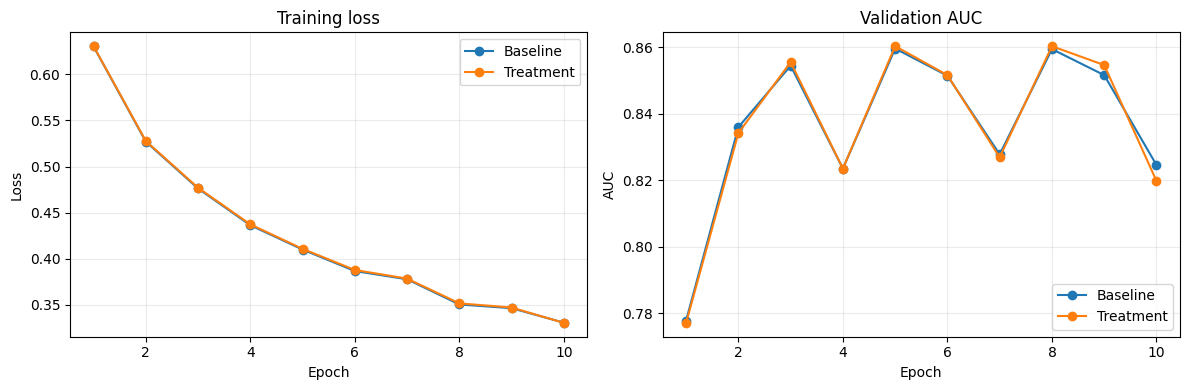

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, hist in [('Baseline', baseline_history), ('Treatment', treatment_history)]:
    axes[0].plot(hist['epoch'], hist['train_loss'], marker='o', label=name)
    axes[1].plot(hist['epoch'], hist['val_auc'], marker='o', label=name)
axes[0].set(title='Training loss', xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Validation AUC', xlabel='Epoch', ylabel='AUC')
for ax in axes:
    ax.grid(alpha=.25); ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=160, bbox_inches='tight')
plt.show()

## 10) compare model on the test set


In [12]:
def best_f1_threshold(y_true, prob):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = [f1_score(y_true, prob >= t) for t in thresholds]
    return float(thresholds[int(np.argmax(scores))])

def evaluate_model(name, model):
    val_y, val_prob, _, _ = predict(model, val_loader)
    threshold = best_f1_threshold(val_y, val_prob)

    test_y, test_prob, record_idx, _ = predict(model, test_loader)
    pred = (test_prob >= threshold).astype(int)
    metrics = {
        'model': name,
        'threshold_from_validation': threshold,
        'AUC': roc_auc_score(test_y, test_prob),
        'AP': average_precision_score(test_y, test_prob),
        'F1': f1_score(test_y, pred),
        'Accuracy': accuracy_score(test_y, pred),
        'TN': int(confusion_matrix(test_y, pred)[0, 0]),
        'FP': int(confusion_matrix(test_y, pred)[0, 1]),
        'FN': int(confusion_matrix(test_y, pred)[1, 0]),
        'TP': int(confusion_matrix(test_y, pred)[1, 1]),
    }
    predictions = pd.DataFrame({
        'record_index': record_idx,
        'ecg_id': small_meta.iloc[record_idx]['ecg_id'].to_numpy(),
        'label': test_y.astype(int),
        'probability_mi': test_prob,
        'prediction': pred,
    })
    predictions.to_csv(OUTPUT_DIR / f'{name}_test_predictions.csv', index=False)
    return metrics

results = pd.DataFrame([
    evaluate_model('baseline', baseline_model),
    evaluate_model('treatment', treatment_model),
])
results.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
display(results.round(4))

,model,threshold_from_validation,AUC,AP,F1,Accuracy,TN,FP,FN,TP
0,baseline,0.5,0.8884,0.8792,0.8250,0.8133,56,19,9,66
1,treatment,0.5,0.8884,0.8801,0.8302,0.8200,57,18,9,66


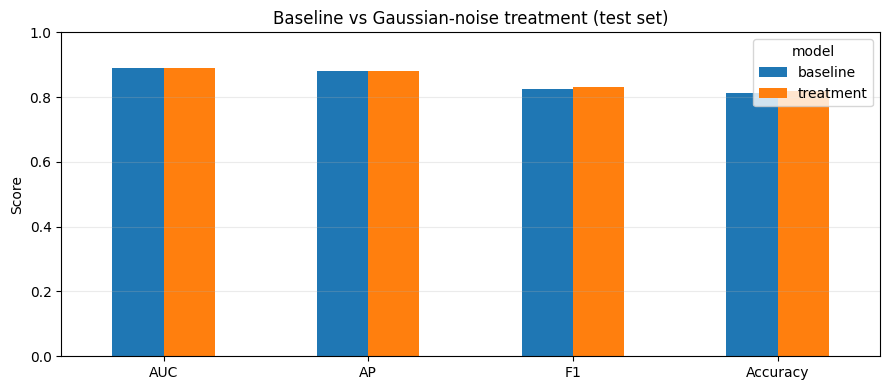

In [13]:
metric_names = ['AUC', 'AP', 'F1', 'Accuracy']
ax = results.set_index('model')[metric_names].T.plot(
    kind='bar', figsize=(9, 4), ylim=(0, 1), rot=0
)
ax.set_title('Baseline vs Gaussian-noise treatment (test set)')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

## 11) Explainable AI: Integrated Gradients


In [14]:
from captum.attr import IntegratedGradients

treatment_model.eval()
test_y, test_prob, test_record_idx, _ = predict(treatment_model, test_loader)
mi_positions = np.where(test_y == 1)[0]
chosen_pos = mi_positions[np.argmax(test_prob[mi_positions])]
chosen_record_idx = int(test_record_idx[chosen_pos])

input_ecg = torch.from_numpy(X[chosen_record_idx:chosen_record_idx + 1]).to(DEVICE)
input_ecg.requires_grad_(True)
baseline = torch.zeros_like(input_ecg)

ig = IntegratedGradients(treatment_model)
attributions, convergence_delta = ig.attribute(
    input_ecg,
    baselines=baseline,
    n_steps=64,
    return_convergence_delta=True,
)

attr = attributions.detach().cpu().numpy()[0]  # [leads, time]
ecg = input_ecg.detach().cpu().numpy()[0]
prob_mi = float(torch.sigmoid(treatment_model(input_ecg)).item())

lead_importance = np.mean(np.abs(attr), axis=1)
lead_importance = lead_importance / (lead_importance.sum() + 1e-12)
lead_df = pd.DataFrame({'lead': lead_names, 'importance': lead_importance})
lead_df = lead_df.sort_values('importance', ascending=False).reset_index(drop=True)
lead_df.to_csv(OUTPUT_DIR / 'integrated_gradients_lead_importance.csv', index=False)

print('ECG ID:', int(small_meta.iloc[chosen_record_idx]['ecg_id']))
print('True label: MI')
print(f'Predicted P(MI): {prob_mi:.4f}')
print(f'Convergence delta: {float(convergence_delta.item()):.6f}')
display(lead_df)

ECG ID: 1918
True label: MI
Predicted P(MI): 0.9945
Convergence delta: 0.003331


,lead,importance
0,AVL,0.191038
1,III,0.146331
2,I,0.107602
3,AVF,0.100540
4,V2,0.080103
5,V1,0.073494
6,II,0.064418
7,V4,0.057795
8,V3,0.054062
9,AVR,0.045999


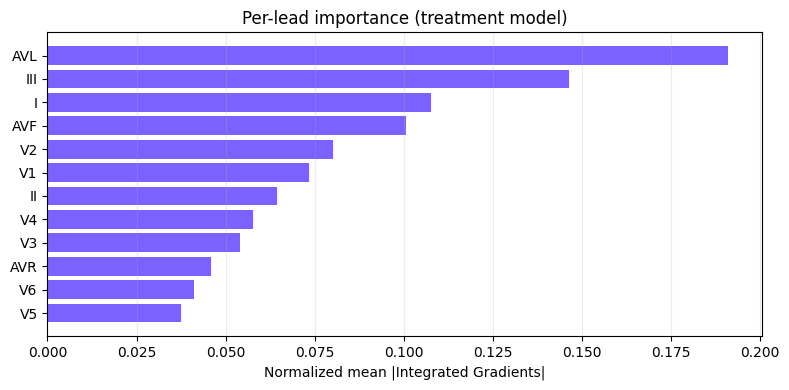

In [15]:
plt.figure(figsize=(8, 4))
ordered = lead_df.sort_values('importance')
plt.barh(ordered['lead'], ordered['importance'], color='#7b61ff')
plt.xlabel('Normalized mean |Integrated Gradients|')
plt.title('Per-lead importance (treatment model)')
plt.grid(axis='x', alpha=.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'integrated_gradients_lead_importance.png', dpi=180, bbox_inches='tight')
plt.show()

### ECG attribution plot


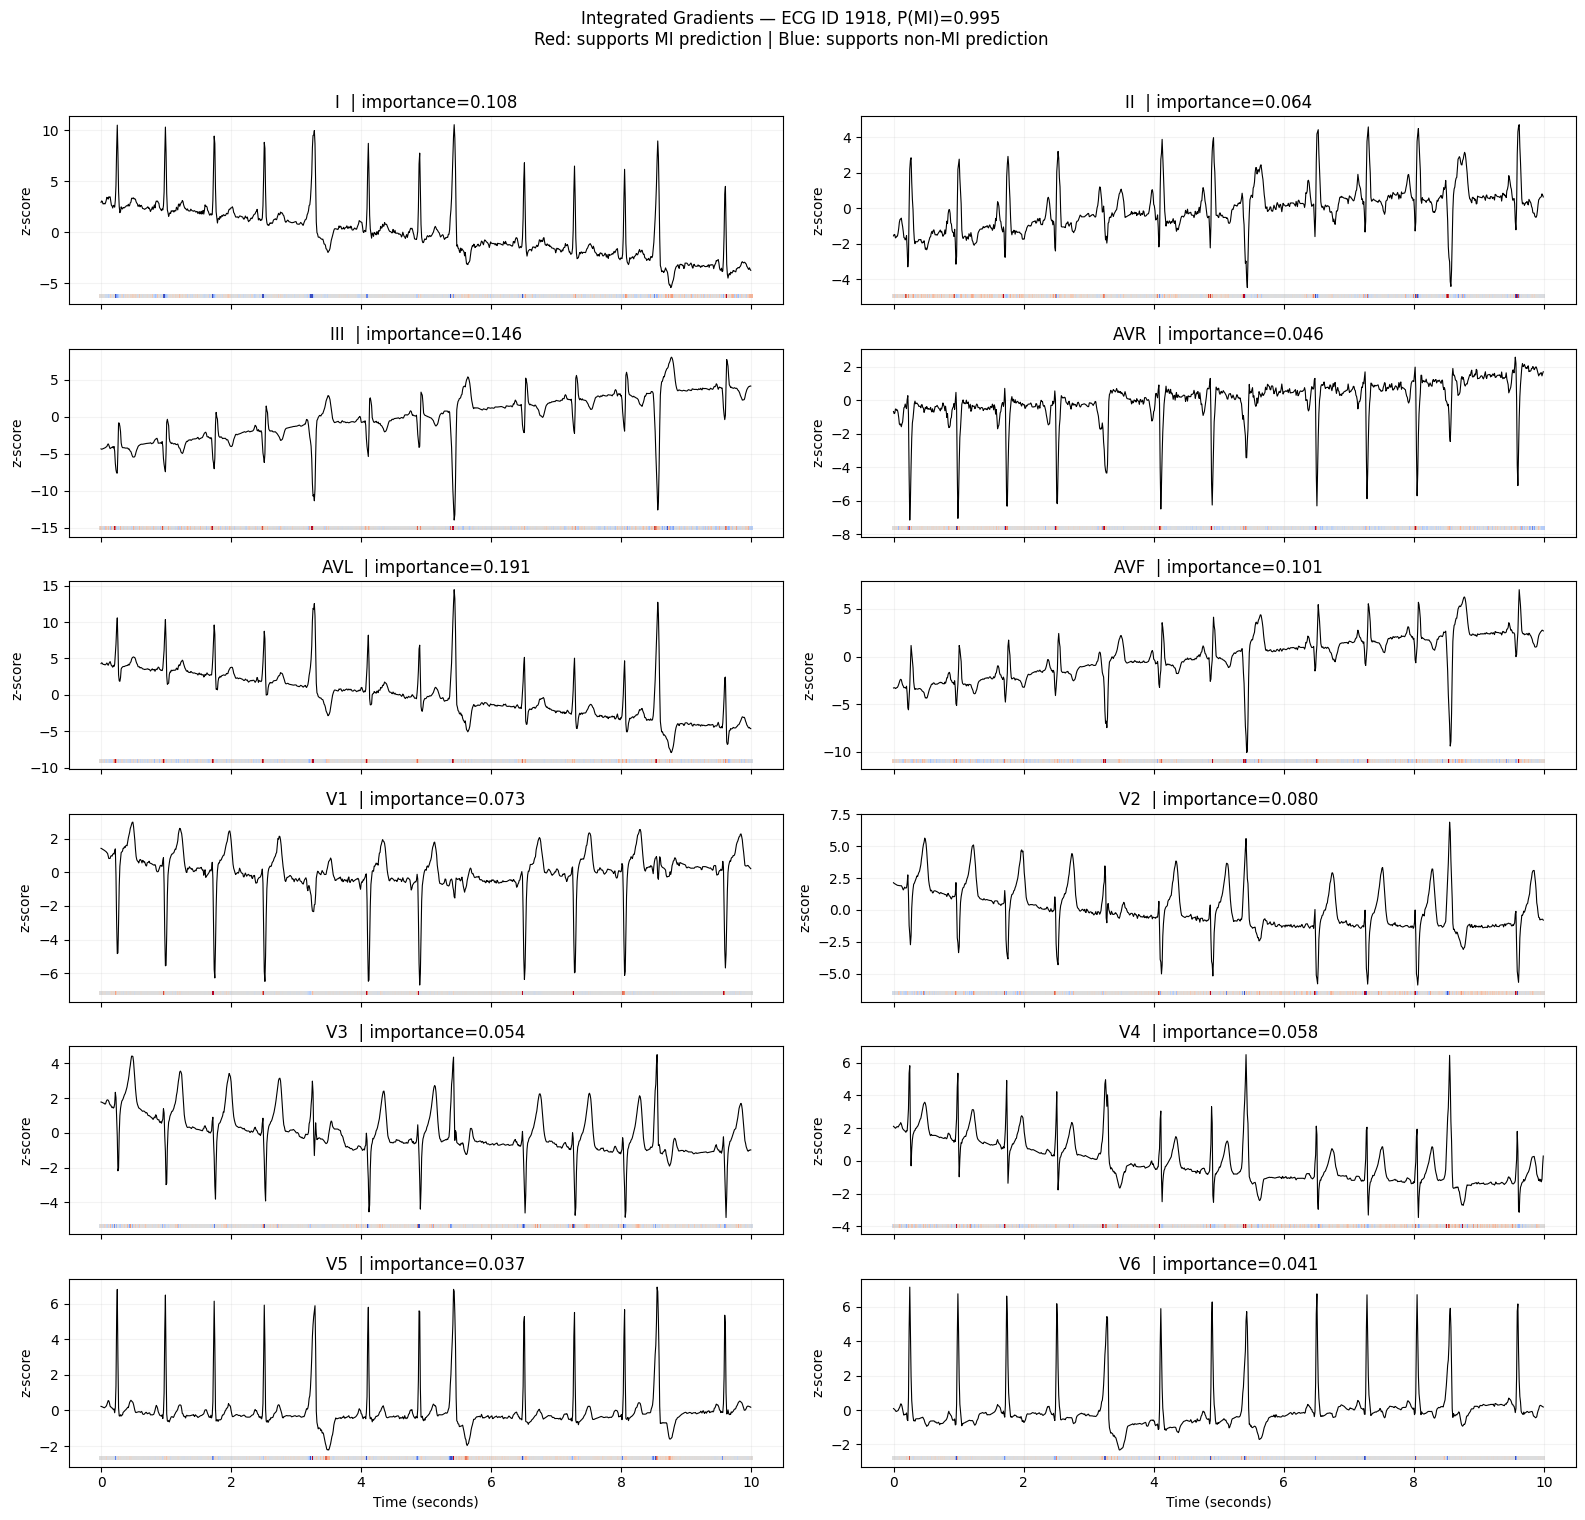

In [16]:
time_s = np.arange(ecg.shape[1]) / 100.0
fig, axes = plt.subplots(6, 2, figsize=(16, 15), sharex=True)
axes = axes.ravel()

for lead_i, ax in enumerate(axes):
    signal = ecg[lead_i]
    a = attr[lead_i]
    scale = np.percentile(np.abs(a), 99) + 1e-12
    a_norm = np.clip(a / scale, -1, 1)

    ax.plot(time_s, signal, color='black', linewidth=0.8)
    y_low, y_high = ax.get_ylim()
    ax.scatter(
        time_s, np.full_like(time_s, y_low), c=a_norm,
        cmap='coolwarm', vmin=-1, vmax=1, s=8, marker='s', linewidths=0
    )
    ax.set_title(f'{lead_names[lead_i]}  | importance={lead_importance[lead_i]:.3f}')
    ax.set_ylabel('z-score')
    ax.grid(alpha=.15)

for ax in axes[-2:]:
    ax.set_xlabel('Time (seconds)')

fig.suptitle(
    f"Integrated Gradients — ECG ID {int(small_meta.iloc[chosen_record_idx]['ecg_id'])}, P(MI)={prob_mi:.3f}\n"
    'Red: supports MI prediction | Blue: supports non-MI prediction',
    y=1.01
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'integrated_gradients_ecg_attribution.png', dpi=180, bbox_inches='tight')
plt.show()

red = signal prediction - MI

blue = signal prediction - Non-MI

## 12) save file

In [17]:
summary = {
    'data_dir': str(DATA_DIR),
    'output_dir': str(OUTPUT_DIR),
    'n_records': int(len(y)),
    'split_sizes': {
        'train': int(len(train_idx)),
        'validation': int(len(val_idx)),
        'test': int(len(test_idx)),
    },
    'seed': SEED,
    'noise_std': NOISE_STD,
    'device': str(DEVICE),
    'results': results.to_dict(orient='records'),
}
with open(OUTPUT_DIR / 'experiment_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved files:')
for path in sorted(OUTPUT_DIR.iterdir()):
    print('-', path.name)

Saved files:
- baseline_best.pt
- baseline_history.csv
- baseline_test_predictions.csv
- experiment_summary.json
- integrated_gradients_ecg_attribution.png
- integrated_gradients_lead_importance.csv
- integrated_gradients_lead_importance.png
- model_comparison.csv
- model_comparison.png
- normalization_stats.npz
- selected_1000_metadata.csv
- selected_1000_metadata_with_split.csv
- training_curves.png
- treatment_best.pt
- treatment_history.csv
- treatment_test_predictions.csv


Gaussian-noise augmentation did not substantially improve discrimination performance. AUC and AP remained nearly unchanged, while F1 and accuracy showed only a small improvement. This suggests that low-level Gaussian noise (σ = 0.02) provides limited regularization benefit for this ECG classification setting.